
# Evaluación 2: Modelado Predictivo de Ingresos Recurrentes (MRR)

* Javiera Cuevas
* Antonia Peña
* Arline Mitchell
* Nicolás Morales

**Fecha de Creación:** Septiembre de 2026  
**Versión:** 1.0  

---

## Descripción
Este notebook contiene el desarrollo para predecir el Ingreso Recurrente Mensual (MRR) del próximo trimestre para la empresa B2B SaaSFlow. El trabajo abarca desde la Fase 1 de Diagnóstico y Calidad de Datos (EDA), luego pasa por la Fase 2 de Limpieza y Tratamiento de Datos, la Fase 3 de Construcción del Modelo de Regresión Lineal, hasta la Fase 4 de Evaluación e Interpretación de Métricas Financieras ($R^2$ y MAE) para la toma de decisiones estratégicas de negocio.

---

## Requisitos de Software
Este notebook fue desarrollado y ejecutado con el uso de las siguientes librerías principales: **Pandas, NumPy, Matplotlib & Seaborn y Scikit-learn**


In [1]:
# ------------------------------------------------------------------
# Importación de todas las librerías utilizadas en el notebook
# (consolidadas al inicio, como buena práctica)
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# Silenciar warnings no críticos para una ejecución limpia
import warnings
warnings.filterwarnings("ignore")




---


# Fase 1: Diagnóstico y Calidad de Datos (Análisis Exploratorio Inicial - EDA)

En esta primera fase, el objetivo es comprender el estado actual del conjunto de datos `clientes_mrr_dataset.csv`. Para ello, realizaremos las siguientes acciones:
1. **Carga de datos:** Importaremos el dataset al entorno.
2. **Análisis de valores nulos:** Calcularemos el porcentaje de datos faltantes por variable para definir la estrategia de imputación en la Fase 2.
3. **Revisión de tipos de datos:** Identificaremos inconsistencias, como fechas en formato de texto o variables categóricas que requieran codificación.
4. **Detección de outliers (valores atípicos):** Utilizaremos medidas de dispersión y diagramas de caja (boxplots) para analizar la distribución de las variables numéricas.

In [2]:
# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# 1. Carga el dataset desde el repositorio
url = "https://raw.githubusercontent.com/javcaves/Inteligencia-Artificial/refs/heads/main/E2%20-%20Regresi%C3%B3n/clientes_mrr_dataset.csv"
df = pd.read_csv(url)

# Visualizar las primeras 5 filas para una inspección rápida
display(df.head())

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


## 1.1 Porcentaje de Valores Nulos
Es fundamental identificar la proporción de datos faltantes. Un porcentaje de nulos nos indicará qué técnica de imputación (mediana, constante o moda) será la más adecuada aplicar en la siguiente etapa del pipeline técnico.

In [3]:
# 2. Calcular el porcentaje de valores nulos por cada variable
nulos_pct = (df.isnull().sum() / len(df)) * 100

# Crear un DataFrame para visualizarlo de forma ordenada
df_nulos = pd.DataFrame({'Porcentaje Faltante (%)': nulos_pct})
df_nulos = df_nulos[df_nulos['Porcentaje Faltante (%)'] > 0].sort_values(by='Porcentaje Faltante (%)', ascending=False)

print("Porcentaje de valores nulos por variable:")
display(df_nulos)

Porcentaje de valores nulos por variable:


,Porcentaje Faltante (%)
satisfaccion_nps,11.990000
tickets_soporte,8.213333
promedio_sesiones_mes,5.150000


## 1.2 Identificación de Tipos de Datos Inconsistentes
Revisaremos la estructura del DataFrame para detectar tipos de datos que no coincidan con su naturaleza. Por ejemplo, la variable `fecha_registro` suele cargarse como texto y deberá transformarse a formato numérico (antigüedad en días), y las variables cualitativas requerirán codificación posteriormente.

In [4]:
# 3. Mostrar información del DataFrame para ver los tipos de datos actuales
print("Información estructural del dataset:\n")
df.info()

print("\n--- Observaciones de Inconsistencias ---")
print("1. Verificar si 'fecha_registro' está como 'object' (texto). Si es así, requiere conversión.")
print("2. Las variables categóricas ('sector_empresa', 'tamano_empresa', 'duracion_contrato', 'pago_puntual') están como tipo 'object' y requerirán Ordinal o One-Hot Encoding.")

Información estructural del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB

--- Observaciones de Inconsistencias ---
1. Verificar si 'fecha_registro' está como 'object' (texto). Si es así, requiere co

## 1.3 Detección de Valores Sesgados y Registros Atípicos (Outliers)
Para las variables numéricas, analizaremos su dispersión estadística (media, desviación estándar, mínimos y máximos). Además, generaremos diagramas de caja (boxplots) que nos permitirán identificar visualmente si existen valores que se escapan de la distribución esperada y que puedan introducir ruido en el modelo de regresión lineal.

Resumen estadístico de las variables numéricas:


,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,mrr_proximo_trimestre
count,27536.000000,28455.000000,26403.000000,30000.000000,30000.000000
mean,3.005121,50.130595,5.913911,2551.090539,710.926286
std,1.734139,45.058935,2.312062,1416.112727,337.688948
min,0.000000,5.001555,1.000000,100.355894,50.000000
25%,2.000000,18.086442,4.000000,1330.525002,458.985000
50%,3.000000,36.230789,6.000000,2541.073850,642.595000
75%,4.000000,67.451126,8.000000,3785.665164,896.705000
max,12.000000,430.701397,10.000000,4999.953843,3200.040000


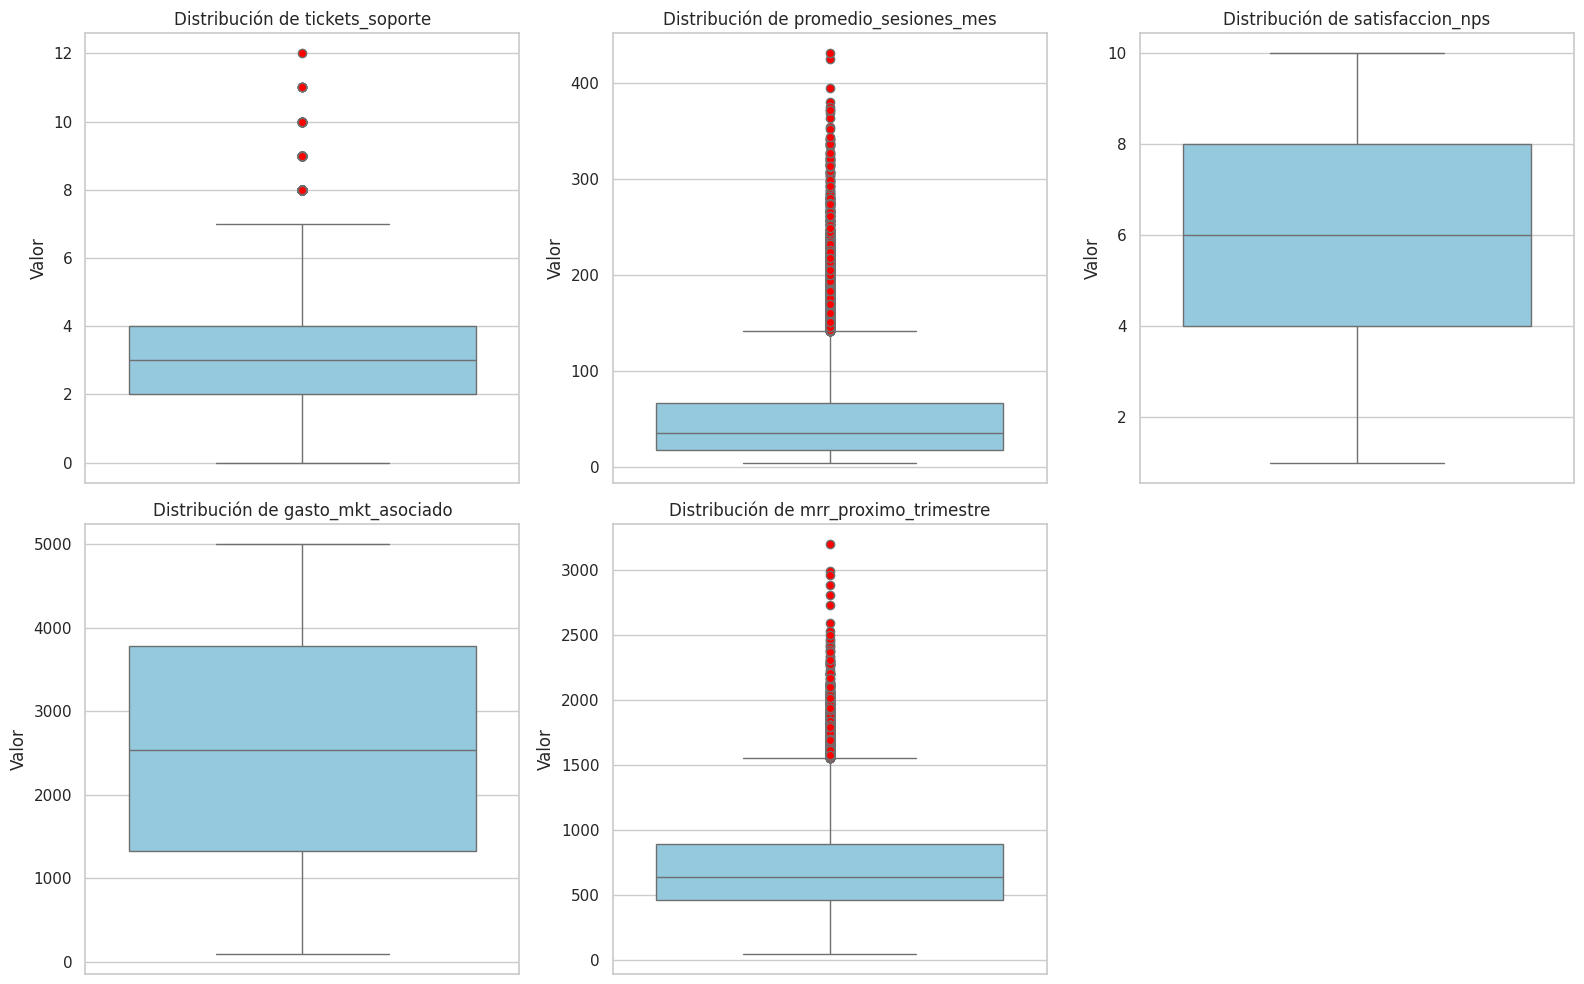

In [5]:
# 4. Detectar valores sesgados y outliers

# Seleccionamos las variables numéricas definidas en la metadata (excluyendo id_cliente)
variables_numericas = ['tickets_soporte', 'promedio_sesiones_mes', 'satisfaccion_nps', 'gasto_mkt_asociado', 'mrr_proximo_trimestre']

# Resumen estadístico (medidas de dispersión)
print("Resumen estadístico de las variables numéricas:")
display(df[variables_numericas].describe())

# Generar Boxplots para cada variable numérica
plt.figure(figsize=(16, 10))

for i, col in enumerate(variables_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue', flierprops=dict(markerfacecolor='red', marker='o', markersize=6))
    plt.title(f'Distribución de {col}', fontsize=12)
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

## Conclusiones de la Fase 1
* **Nulos:** Se detectaron valores faltantes en tres variables: `satisfaccion_nps` con un 11.99%, `tickets_soporte` con un 8.21% y `promedio_sesiones_mes` con un 5.15%. Estos porcentajes determinarán las estrategias de imputación (mediana o valor modal) para la siguiente etapa.
* **Inconsistencias:** La variable `fecha_registro` ingresó como tipo de dato `object` (cadena de texto) e incluye marcas de tiempo complejas, lo que obligará a convertirla en una variable numérica calculable, como la antigüedad en días. Las variables cualitativas `sector_empresa`, `tamano_empresa`, `duracion_contrato` y `pago_puntual` están estructuradas como `object` y requieren codificación obligatoria para ser procesadas por el modelo de regresión.
* **Outliers:** El análisis visual mediante diagramas de caja muestra una clara presencia de valores atípicos superiores (marcados en rojo) en las variables `tickets_soporte`, `promedio_sesiones_mes` y en la variable objetivo `mrr_proximo_trimestre`. Por el contrario, las variables `satisfaccion_nps` y `gasto_mkt_asociado` exhiben una dispersión controlada y carecen de valores atípicos que escapen de sus límites estadísticos.



---


# Fase 2: Limpieza y Tratamiento de Datos (Preprocesamiento e Ingeniería de Características.)

En esta fase se preparan las variables para que puedan ser utilizadas por el modelo de regresión lineal.

Las acciones realizadas son:

1. **Tratamiento de valores nulos**
   - `promedio_sesiones_mes`: imputación por **mediana**, adecuada porque la variable presenta asimetría y valores extremos.
   - `tickets_soporte`: imputación por **moda**, al ser una variable discreta de conteo.
   - `satisfaccion_nps`: imputación por **moda**. A diferencia de `promedio_sesiones_mes`, esta variable no presentó atípicos en la Fase 1 (ver boxplot); se elige moda y no promedio porque es una escala discreta tipo Likert (1 a 10), donde el promedio podría generar valores fraccionarios sin sentido real (ej. 6.37), mientras que la moda conserva un valor efectivamente observable en la escala.

2. **Ingeniería de características**
   - `fecha_registro` se transforma en `antiguedad_dias`.
   - `duracion_contrato` se transforma a meses: Mensual = 1, Anual = 12 y 2 Años = 24.
   - `pago_puntual` se transforma a binario: No = 0, Sí = 1.

3. **Codificación categórica**
   - `tamano_empresa`: Ordinal Encoding, respetando la jerarquía Pequeña < Mediana < Grande.
   - `sector_empresa`: One-Hot Encoding.

4. **Escalado**
   - Se utiliza `RobustScaler` en variables numéricas para reducir la influencia de valores atípicos.

> **Prevención de data leakage:** las transformaciones que aprenden parámetros de los datos (imputación, escalado y codificación) se **definen** en esta fase, pero se deben ajustar (`fit`) únicamente con el conjunto de entrenamiento en la Fase 3.

## 2.1 Ingeniería de características y mapeos determinísticos

Estas transformaciones no calculan estadísticas sobre la variable objetivo, por lo que pueden prepararse antes de la división entrenamiento/prueba.

In [6]:
# Trabajar sobre una copia para conservar el DataFrame original de la Fase 1
df_modelo = df.copy()

# 1) Convertir la fecha desde texto a datetime
df_modelo["fecha_registro"] = pd.to_datetime(
    df_modelo["fecha_registro"],
    errors="coerce"
)

# Verificar que todas las fechas hayan sido interpretadas correctamente
if df_modelo["fecha_registro"].isna().any():
    raise ValueError("Existen fechas que no pudieron convertirse correctamente.")

# 2) Crear antigüedad del cliente en días.
# Se fija una fecha de corte para que el cálculo sea reproducible.
fecha_corte = pd.Timestamp("2026-01-01")
df_modelo["antiguedad_dias"] = (
    fecha_corte - df_modelo["fecha_registro"]
).dt.days

# 3) Mapear duración del contrato a meses (representación numérica interpretable)
mapa_duracion = {
    "Mensual": 1,
    "Anual": 12,
    "2 Años": 24
}
df_modelo["duracion_contrato_meses"] = (
    df_modelo["duracion_contrato"].map(mapa_duracion)
)

# 4) Mapear pago puntual a variable binaria
mapa_pago = {
    "No": 0,
    "Si": 1
}
df_modelo["pago_puntual_bin"] = (
    df_modelo["pago_puntual"].map(mapa_pago)
)

# Validar que no aparecieron NaN por categorías inesperadas
if df_modelo[["duracion_contrato_meses", "pago_puntual_bin"]].isna().any().any():
    raise ValueError("Se encontraron categorías no contempladas en los mapeos.")

# Separar predictores y variable objetivo.
# id_cliente se elimina porque es solo un identificador.
X = df_modelo.drop(columns=[
    "id_cliente",
    "fecha_registro",
    "duracion_contrato",
    "pago_puntual",
    "mrr_proximo_trimestre"
])

y = df_modelo["mrr_proximo_trimestre"]

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
display(X.head())


Dimensión de X: (30000, 9)
Dimensión de y: (30000,)


,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,antiguedad_dias,duracion_contrato_meses,pago_puntual_bin
0,Finanzas,Mediana,3.0,34.350838,7.0,3932.341944,108,1,1
1,Tecnologia,Mediana,NaN,28.685569,8.0,2547.833298,688,1,0
2,Tecnologia,Pequeña,5.0,50.027033,7.0,3203.232664,1792,24,1
3,Educacion,Pequeña,0.0,NaN,9.0,603.209270,1595,12,0
4,Educacion,Grande,3.0,NaN,8.0,864.788600,1557,12,1


## 2.2 Pipeline de imputación, codificación y escalado

Se utiliza `ColumnTransformer` para aplicar una estrategia diferente según la naturaleza de cada variable.  
Este objeto quedará listo para ser utilizado en la Fase 3 después de dividir los datos.


In [7]:
# --- Promedio de sesiones ---
# Mediana por su distribución asimétrica + RobustScaler por presencia de outliers
pipeline_sesiones = Pipeline(steps=[
    ("imputacion_mediana", SimpleImputer(strategy="median")),
    ("escalado_robusto", RobustScaler())
])

# --- Tickets de soporte y satisfacción NPS ---
# Moda por tratarse de variables discretas
pipeline_discretas = Pipeline(steps=[
    ("imputacion_moda", SimpleImputer(strategy="most_frequent")),
    ("escalado_robusto", RobustScaler())
])

# --- Variables numéricas sin nulos ---
pipeline_continuas = Pipeline(steps=[
    ("escalado_robusto", RobustScaler())
])

# --- Tamaño de empresa: variable ordinal ---
pipeline_tamano = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(
        categories=[["Pequeña", "Mediana", "Grande"]],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

# --- Sector: variable nominal ---
# drop="first" evita redundancia perfecta entre las variables dummy
pipeline_sector = Pipeline(steps=[
    ("one_hot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Preprocesador general
preprocesador = ColumnTransformer(
    transformers=[
        ("sesiones",
         pipeline_sesiones,
         ["promedio_sesiones_mes"]),

        ("discretas",
         pipeline_discretas,
         ["tickets_soporte", "satisfaccion_nps"]),

        ("continuas",
         pipeline_continuas,
         ["gasto_mkt_asociado", "antiguedad_dias", "duracion_contrato_meses"]),

        ("tamano",
         pipeline_tamano,
         ["tamano_empresa"]),

        ("sector",
         pipeline_sector,
         ["sector_empresa"]),

        ("pago_binario",
         "passthrough",
         ["pago_puntual_bin"])
    ],
    remainder="drop"
)

print("Preprocesador definido correctamente.")
print("Importante: todavía NO se ejecuta fit() para evitar data leakage.")


Preprocesador definido correctamente.
Importante: todavía NO se ejecuta fit() para evitar data leakage.


## 2.3 Resumen de las decisiones de preprocesamiento


In [8]:
resumen_preprocesamiento = pd.DataFrame({
    "Variable": [
        "promedio_sesiones_mes",
        "tickets_soporte",
        "satisfaccion_nps",
        "fecha_registro",
        "tamano_empresa",
        "sector_empresa",
        "duracion_contrato",
        "pago_puntual",
        "Variables numéricas"
    ],
    "Tratamiento": [
        "Imputación por mediana + RobustScaler",
        "Imputación por moda + RobustScaler",
        "Imputación por moda + RobustScaler",
        "Conversión a antiguedad_dias",
        "Ordinal Encoding: Pequeña < Mediana < Grande",
        "One-Hot Encoding (drop='first')",
        "Mapeo a meses: 1 / 12 / 24",
        "Mapeo binario: No=0 / Si=1",
        "RobustScaler para reducir influencia de outliers"
    ]
})

display(resumen_preprocesamiento)


,Variable,Tratamiento
0,promedio_sesiones_mes,Imputación por mediana + RobustScaler
1,tickets_soporte,Imputación por moda + RobustScaler
2,satisfaccion_nps,Imputación por moda + RobustScaler
3,fecha_registro,Conversión a antiguedad_dias
4,tamano_empresa,Ordinal Encoding: Pequeña < Mediana < Grande
5,sector_empresa,One-Hot Encoding (drop='first')
6,duracion_contrato,Mapeo a meses: 1 / 12 / 24
7,pago_puntual,Mapeo binario: No=0 / Si=1
8,Variables numéricas,RobustScaler para reducir influencia de outliers


## 2.4 Uso correcto del preprocesador en la Fase 3

Para evitar **data leakage**, en la Fase 3 primero se divide el dataset. Luego:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)
```

De esta forma, la mediana, la moda, los parámetros de escalado y las categorías del One-Hot Encoding se aprenden **solo a partir del conjunto de entrenamiento**.


## Conclusiones de la Fase 2

* Los valores faltantes se tratarán con estrategias acordes a la naturaleza de cada variable: mediana para `promedio_sesiones_mes` y moda para `tickets_soporte` y `satisfaccion_nps`.
* `fecha_registro` fue convertida en `antiguedad_dias`, una variable numérica útil para representar la permanencia del cliente.
* Las variables categóricas quedaron preparadas mediante codificación ordinal, One-Hot Encoding y mapeos numéricos/binarios.
* Se seleccionó `RobustScaler` para disminuir la sensibilidad del preprocesamiento frente a los valores atípicos observados en la Fase 1.
* El preprocesador se dejó definido sin ajustarlo sobre el dataset completo; su `fit` debe hacerse únicamente con los datos de entrenamiento en la Fase 3 para evitar fuga de información.




---


# Fase 3 : Construcción del Modelo  (Entrenamiento y creación del modelo.)

Se ajusta un algoritmo de Regresión Lineal con las características procesadas y estandarizadas de entrenamiento (`X_train_scaled` y `y_train`).

## 3.1 División en entrenamiento y prueba

Los datos se dividen antes de imputar, escalar o codificar, de modo que el preprocesador se ajuste solo con el conjunto de entrenamiento (80%) y el conjunto de prueba (20%) quede sin usar hasta la evaluación. Se fija `random_state=42` para que la división sea reproducible.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} clientes ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba:        {X_test.shape[0]} clientes ({X_test.shape[0]/len(X):.0%})")

print("\nMRR medio (entrenamiento):", round(y_train.mean(), 2), "USD")
print("MRR medio (prueba):       ", round(y_test.mean(), 2), "USD")

# La antigüedad no debería ser negativa con la fecha de corte definida en la Fase 2
print("Antigüedad mínima (días):", X["antiguedad_dias"].min())

Entrenamiento: 24000 clientes (80%)
Prueba:        6000 clientes (20%)

MRR medio (entrenamiento): 711.58 USD
MRR medio (prueba):        708.31 USD
Antigüedad mínima (días): 1


## 3.2 Entrenamiento de la Regresión Lineal

El preprocesador de la Fase 2 y la regresión se unen en un `Pipeline`. Al ejecutar `fit` con los datos de entrenamiento, la imputación, el escalado y la codificación se aprenden solo con ese conjunto, y luego se aplican con los mismos parámetros sobre el conjunto de prueba.

In [10]:
modelo = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("regresion", LinearRegression())
])

modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print("Variables de entrada a la regresión:", modelo.named_steps["regresion"].n_features_in_)
print("Intercepto (USD):", round(modelo.named_steps["regresion"].intercept_, 2))

Modelo entrenado.
Variables de entrada a la regresión: 12
Intercepto (USD): 239.97


## Conclusiones de la Fase 3
* La división 80/20 se realizó antes de cualquier transformación que aprenda parámetros de los datos.
* El Pipeline se ajustó únicamente con X_train e y_train.
* La variable objetivo se mantuvo en su escala original (USD).



---


# Fase 4: Evaluación e Interpretación de Métricas (Validación en el conjunto de prueba)

Se obtienen las predicciones sobre el conjunto de prueba y se evalúan mediante:
* **$R^2$ (Coeficiente de Determinación):** Proporción de la varianza del MRR explicada por el modelo.
* **MAE (Error Absoluto Medio):** Magnitud promedio del error en unidades monetarias reales ($ USD).

## 4.1 Métricas en el conjunto de prueba
Se calculan el R² (proporción de la varianza del MRR explicada por el modelo) y el MAE (error absoluto promedio, en USD). Además, se comparan con las métricas de entrenamiento, para revisar si hay sobreajuste, y con un modelo base que siempre predice el MRR promedio.

In [11]:
y_pred_test = modelo.predict(X_test)
y_pred_train = modelo.predict(X_train)

r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

# Modelo base: predice siempre el promedio del conjunto de entrenamiento
base = DummyRegressor(strategy="mean").fit(X_train, y_train)
mae_base = mean_absolute_error(y_test, base.predict(X_test))

mrr_medio = y_test.mean()

tabla_metricas = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba", "Modelo base (siempre el promedio)"],
    "R²": [f"{r2_train:.3f}", f"{r2_test:.3f}", "0.000"],
    "MAE (USD)": [f"{mae_train:,.2f}", f"{mae_test:,.2f}", f"{mae_base:,.2f}"]
})

display(tabla_metricas)

,Conjunto,R²,MAE (USD)
0,Entrenamiento,0.919,69.60
1,Prueba,0.924,68.34
2,Modelo base (siempre el promedio),0.000,266.61


## 4.2 Valores reales vs. predichos
Los puntos cercanos a la diagonal corresponden a predicciones precisas. El histograma muestra cómo se distribuyen los errores.

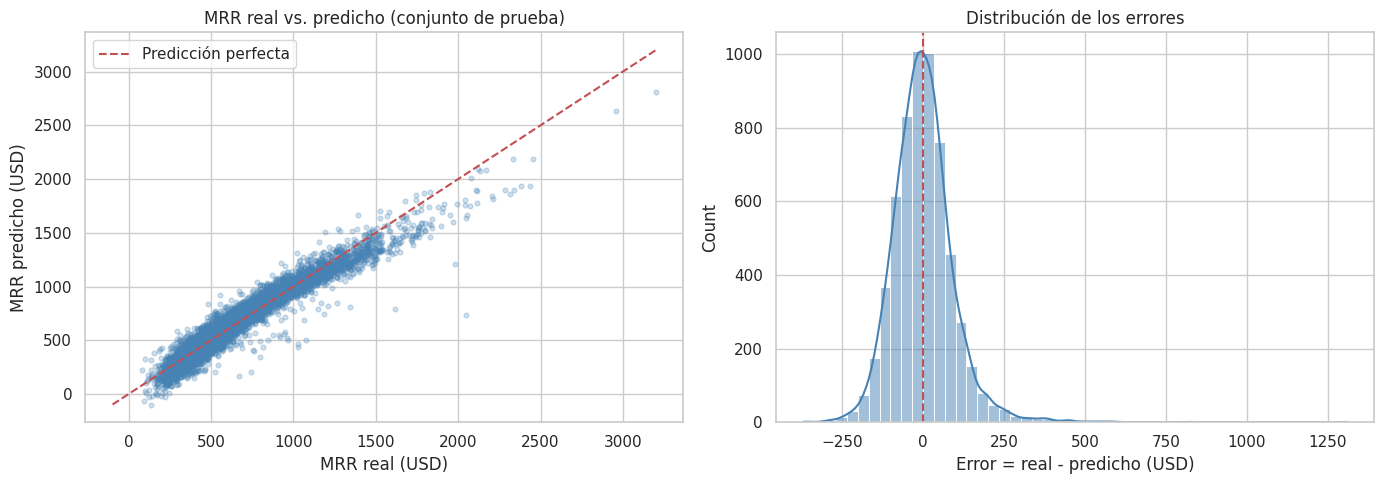

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.25, s=12, color="steelblue")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--", label="Predicción perfecta")
axes[0].set_xlabel("MRR real (USD)")
axes[0].set_ylabel("MRR predicho (USD)")
axes[0].set_title("MRR real vs. predicho (conjunto de prueba)")
axes[0].legend()

residuos = y_test - y_pred_test
sns.histplot(residuos, bins=50, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Error = real - predicho (USD)")
axes[1].set_title("Distribución de los errores")

plt.tight_layout()
plt.show()

## 4.3 Resumen de las métricas en términos financieros

In [13]:
error_total = (y_pred_test.sum() - y_test.sum()) / y_test.sum()

resumen_financiero = pd.DataFrame({
    "Métrica": [
        "R² (prueba)",
        "MAE (prueba)",
        "MAE / MRR promedio",
        "Reducción del error vs. modelo base",
        "MRR total predicho vs. real"
    ],
    "Valor": [
        f"{r2_test:.3f}",
        f"{mae_test:,.2f} USD",
        f"{mae_test/mrr_medio:.1%}",
        f"{(1 - mae_test/mae_base):.1%}",
        f"{error_total:+.2%}"
    ],
    "Interpretación": [
        f"El modelo explica el {r2_test:.1%} de la variación del MRR",
        f"Error promedio de ~{mae_test:,.0f} USD por cliente",
        f"El error es ese % del MRR promedio ({mrr_medio:,.0f} USD)",
        f"Frente al modelo base (MAE {mae_base:,.0f} USD), el error baja ese %",
        "Los errores individuales se compensan al sumar clientes"
    ]
})

with pd.option_context("display.max_colwidth", None):
    display(resumen_financiero)

,Métrica,Valor,Interpretación
0,R² (prueba),0.924,El modelo explica el 92.4% de la variación del MRR
1,MAE (prueba),68.34 USD,Error promedio de ~68 USD por cliente
2,MAE / MRR promedio,9.6%,El error es ese % del MRR promedio (708 USD)
3,Reducción del error vs. modelo base,74.4%,"Frente al modelo base (MAE 267 USD), el error baja ese %"
4,MRR total predicho vs. real,-0.07%,Los errores individuales se compensan al sumar clientes


## Conclusiones de la Fase 4
* R²: el modelo explica el 92.4% de la variabilidad del MRR en clientes que no vio durante el entrenamiento. El R² de entrenamiento (0.919) es muy similar, por lo que no hay sobreajuste.
* MAE: el modelo se equivoca en promedio 68.34 USD por cliente, cerca del 9.6% del MRR promedio (708 USD). Frente a un modelo que siempre predice el promedio (266.61 USD), el error se reduce en 74.4%.